In [ ]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from yellowbrick.cluster import KElbowVisualizer


In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')
# https://towardsdatascience.com/customer-segmentation-using-k-means-clustering-d33964f238c3
! kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python

In [ ]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
15,16,Male,22,20,79
107,108,Male,54,63,46
72,73,Female,60,50,49
183,184,Female,29,98,88
146,147,Male,48,77,36


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df['Gender'] = df['Gender'].astype('category').cat.codes

In [ ]:
df.set_index('CustomerID', inplace=True)

In [ ]:
df.sample(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
111,1,65,63,52
6,0,22,17,76
37,0,42,34,17
199,1,32,137,18
102,0,49,62,48


In [ ]:
df.columns = ['genero', 'idade', 'renda_anual', 'nivel_gastos']

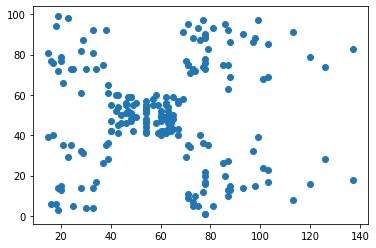

In [ ]:
plt.scatter(df.renda_anual, df.nivel_gastos)
plt.show()

In [ ]:
df1 = df[['renda_anual', 'nivel_gastos']]
x = df1.values

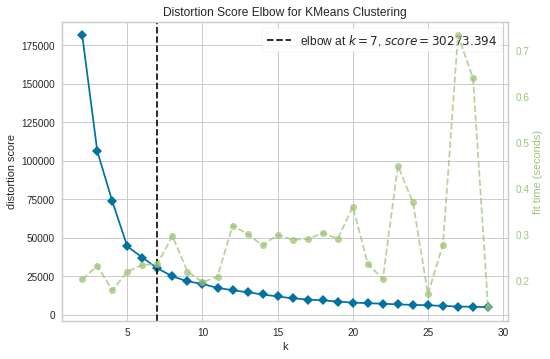

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,30), timings= True)
visualizer.fit(x)
visualizer.show()

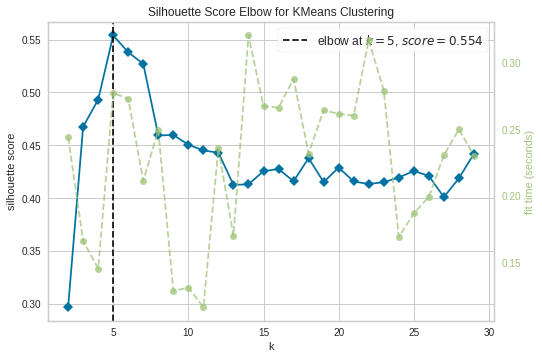

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,30),metric='silhouette', timings= True)
visualizer.fit(x)
visualizer.show()

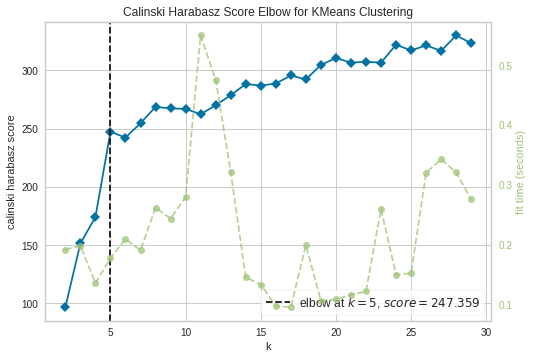

In [ ]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,30),metric='calinski_harabasz', timings= True)
visualizer.fit(x)
visualizer.show()

In [ ]:
kmeans_final = KMeans(n_clusters=5)

In [ ]:
kmeans_final.fit(x)

KMeans(n_clusters=5)

In [ ]:
cluster_pred = kmeans_final.predict(x)

In [ ]:
cluster_centers = kmeans_final.cluster_centers_

In [ ]:
cluster_centers

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [88.2       , 17.11428571],
       [25.72727273, 79.36363636],
       [26.30434783, 20.91304348]])

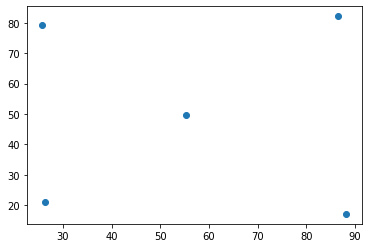

In [ ]:
plt.scatter(cluster_centers[:,0], cluster_centers[:,1])
plt.show()

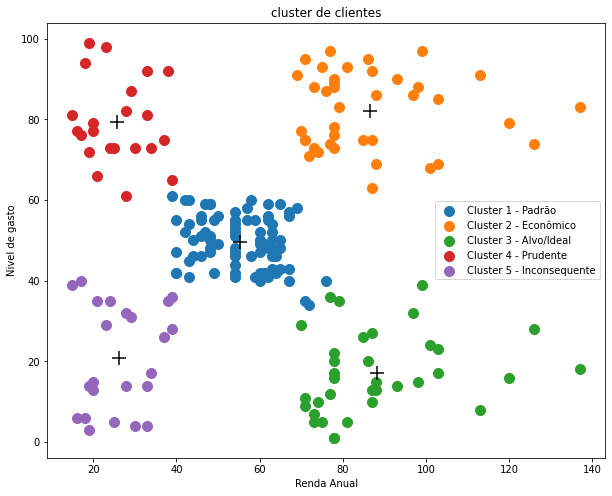

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(x[cluster_pred==0, 0], x[cluster_pred==0, 1],s=100, label='Cluster 1 - Padrão')
plt.scatter(x[cluster_pred==1, 0], x[cluster_pred==1, 1],s=100, label='Cluster 2 - Econômico')
plt.scatter(x[cluster_pred==2, 0], x[cluster_pred==2, 1],s=100, label='Cluster 3 - Alvo/Ideal')
plt.scatter(x[cluster_pred==3, 0], x[cluster_pred==3, 1],s=100, label='Cluster 4 - Prudente')
plt.scatter(x[cluster_pred==4, 0], x[cluster_pred==4, 1],s=100, label='Cluster 5 - Inconsequente')
plt.scatter(cluster_centers[:,0],cluster_centers[:,1], marker='+', s=200, c='black')
plt.legend()
plt.title('cluster de clientes')
plt.xlabel('Renda Anual')
plt.ylabel('Nivel de gasto')
plt.show()

#### Aplique o algoritmo declusterização Kmeans no dataset wine

Disponível no Classroom.
